# 5. Redundancia, fuga de información y techo de desempeño

Este capítulo cierra la fase exploratoria con cuatro asuntos que condicionan directamente el diseño del pipeline: la redundancia entre predictores, la geometría de la matriz que los modelos van a recibir de verdad, el grado de solapamiento entre las clases y la revisión de fuga de información.

La sección 5.4 es la más importante para leer el resto del proyecto. Estima, **antes de entrenar ningún modelo**, cuánto desempeño permite alcanzar este conjunto de datos. Sin esa referencia, un AUC de 0.65 en el capítulo 7 puede interpretarse como un fracaso o como un resultado próximo al límite del problema, y la diferencia entre ambas lecturas no es de modelado sino de honestidad en el análisis.

In [1]:
from config import *
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

try:
    from myst_nb import glue as _glue
except ImportError:  # el notebook sigue siendo ejecutable fuera de Jupyter Book
    def _glue(clave, valor, display=False):
        return None


def anotar(clave, valor):
    """Publica un valor para poder citarlo en el texto del capítulo."""
    _glue(clave, str(valor), display=False)
    return valor


roles = roles_variables()
OBJETIVO = roles["objetivo"]
IDENTIFICADOR = roles["identificador"]
NUMERICAS = roles["numericas"] + roles["ordinales"]
CATEGORICAS = roles["categoricas"]
BINARIAS = roles["binarias"]

train = leer_tabla("diabetes_train")
assert train.isna().sum().sum() == 0, "El conjunto cargado tiene faltantes"

objetivo = train[OBJETIVO].to_numpy()
grupos = train[IDENTIFICADOR]

anotar("c5_encuentros", f"{len(train):,}")
print(f"Entrenamiento: {len(train):,} encuentros de {grupos.nunique():,} "
      f"pacientes")

Entrenamiento: 79,473 encuentros de 56,036 pacientes


El análisis se hace, como en los dos capítulos anteriores, sobre los {glue:text}`c5_encuentros` encuentros del conjunto de entrenamiento.

## 5.1. Colinealidad entre variables numéricas

Se usa la correlación de Spearman, apropiada para variables que no cumplen normalidad, y se complementa con el factor de inflación de la varianza (VIF), que detecta dependencias lineales múltiples invisibles en un análisis por pares.

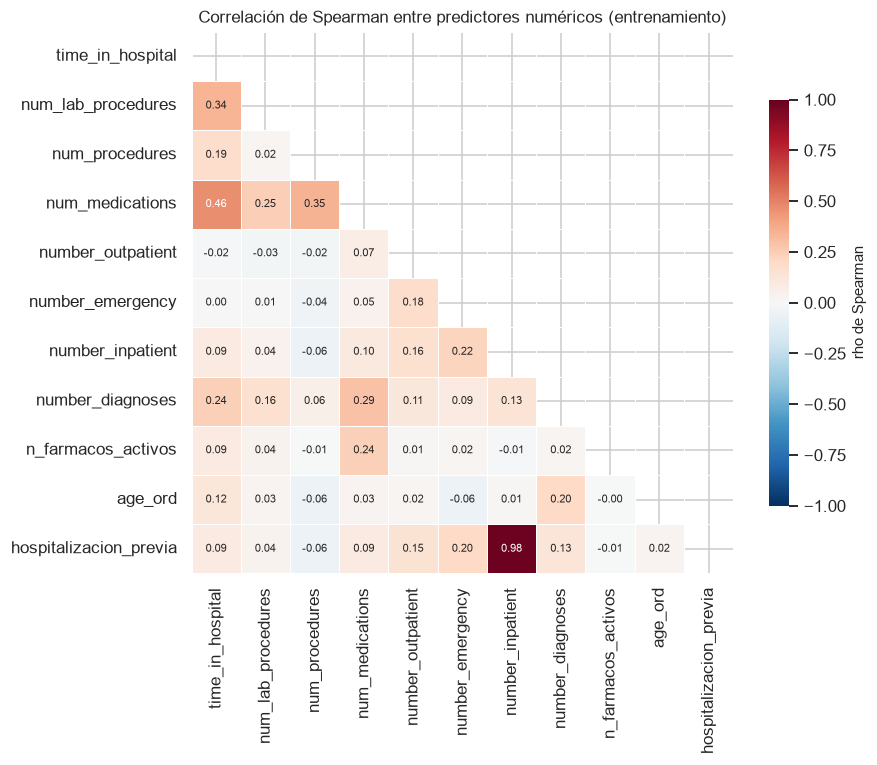

In [2]:
correlaciones = train[NUMERICAS + BINARIAS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
mascara = np.triu(np.ones_like(correlaciones, dtype=bool))
sns.heatmap(correlaciones, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            cbar_kws={"shrink": 0.75, "label": "rho de Spearman"},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlación de Spearman entre predictores numéricos "
             "(entrenamiento)")
plt.tight_layout()
plt.show()

In [3]:
pares = (correlaciones
         .where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool))
         .stack().rename("rho").reset_index())
pares.columns = ["variable_1", "variable_2", "rho"]
pares["|rho|"] = pares["rho"].abs()
# La correlación de Pearson se añade para poder distinguir una relación
# monótona perfecta de una dependencia lineal: no son lo mismo y la
# diferencia decide si hay redundancia real.
pares["r de Pearson"] = [
    train[a].corr(train[b]) for a, b in zip(pares["variable_1"],
                                            pares["variable_2"])]
fuertes = pares.query("`|rho|` > 0.25").sort_values("|rho|", ascending=False)

anotar("c5_par_max", f"{fuertes.iloc[0]['variable_1']} y "
                     f"{fuertes.iloc[0]['variable_2']}")
anotar("c5_rho_max", f"{fuertes.iloc[0]['rho']:.2f}")
anotar("c5_pearson_max", f"{fuertes.iloc[0]['r de Pearson']:.2f}")
tabla(fuertes.round(3), filas=15,
      titulo="Pares de predictores numéricos con correlación apreciable",
      indice=False)

### Pares de predictores numéricos con correlación apreciable

In [4]:
def calcular_vif(datos):
    """Factor de inflación de la varianza de cada variable.

    Se define como ``VIF_j = 1 / (1 - R2_j)``, donde ``R2_j`` proviene de
    regresar la variable j sobre todas las demás con intercepto. Se resuelve
    por mínimos cuadrados para no depender de librerías adicionales.

    Un VIF superior a 5 indica redundancia apreciable y superior a 10,
    colinealidad severa. Valores del orden de 1e12 revelan dependencia lineal
    exacta, es decir, una variable que es combinación de otras.

    Returns
    -------
    pandas.DataFrame
        Variables ordenadas por VIF descendente.
    """
    matriz = np.column_stack([np.ones(len(datos)),
                              datos.astype(float).to_numpy()])
    resultados = []
    for j in range(1, matriz.shape[1]):
        objetivo_j = matriz[:, j]
        resto = np.delete(matriz, j, axis=1)
        coeficientes, *_ = np.linalg.lstsq(resto, objetivo_j, rcond=None)
        residuos = objetivo_j - resto @ coeficientes
        r2 = 1 - residuos.var() / objetivo_j.var()
        resultados.append(1 / max(1e-12, 1 - r2))
    return (pd.DataFrame({"variable": datos.columns, "VIF": resultados})
            .set_index("variable").sort_values("VIF", ascending=False))


vif = calcular_vif(train[NUMERICAS + BINARIAS])
vif["diagnóstico"] = pd.cut(
    vif["VIF"], bins=[0, 5, 10, np.inf],
    labels=["Aceptable", "Redundancia apreciable", "Colinealidad severa"])

anotar("c5_vif_max", f"{vif['VIF'].max():.2f}")
anotar("c5_vif_variable", vif.index[0])
anotar("c5_vif_altos", int((vif["VIF"] > 5).sum()))
tabla(vif.round(2), filas=15,
      titulo="Factor de inflación de la varianza")

### Factor de inflación de la varianza

El diagnóstico es benigno: {glue:text}`c5_vif_altos` variables superan el umbral de 5, con un máximo de {glue:text}`c5_vif_max` en {glue:text}`c5_vif_variable`.

El par de mayor correlación de Spearman es {glue:text}`c5_par_max` (rho = {glue:text}`c5_rho_max`), y merece una lectura cuidadosa para no sacar la conclusión equivocada. La segunda variable es la binarización de la primera, de modo que la relación es monótona perfecta y Spearman, que solo usa rangos, alcanza su valor máximo. Pero eso **no implica dependencia lineal**: la correlación de Pearson entre ambas es {glue:text}`c5_pearson_max` y el VIF de las dos se mantiene dentro de lo aceptable. El valor de Spearman está además inflado por la estructura de empates, ya que la mayoría de las observaciones vale cero en las dos variables. Es un buen recordatorio de que una correlación de rangos cercana a 1 no equivale a redundancia exacta.

Este resultado favorable es consecuencia directa de una corrección aplicada en el capítulo 2. Una versión anterior del conjunto incluía `visitas_previas`, la suma de las tres variables de utilización, junto con sus tres componentes. Eso constituía **dependencia lineal exacta**: el VIF de las cuatro variables se disparaba al orden de 1e12, lo que en la práctica dejaría indeterminados los coeficientes de cualquier modelo lineal. Al conservar solo los componentes, el problema desaparece.

Con este diagnóstico **no se elimina ninguna variable**. Las correlaciones observadas son moderadas y no impiden estimar un modelo lineal regularizado, que es precisamente el mecanismo con el que Ridge y Lasso manejan la colinealidad.

## 5.2. Redundancia entre variables categóricas

Se calcula la V de Cramér entre pares de categóricas para detectar variables que codifican la misma información.

In [5]:
def v_cramer(contingencia):
    """V de Cramér con la corrección por sesgo de Bergsma."""
    chi2 = stats.chi2_contingency(contingencia).statistic
    n = contingencia.values.sum()
    phi2 = chi2 / n
    r, k = contingencia.shape
    phi2_corregido = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corregido = r - (r - 1) ** 2 / (n - 1)
    k_corregido = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corregido /
                   max(1e-12, min(k_corregido - 1, r_corregido - 1)))


matriz_v = pd.DataFrame(index=CATEGORICAS, columns=CATEGORICAS, dtype=float)
for i, primera in enumerate(CATEGORICAS):
    for segunda in CATEGORICAS[i:]:
        valor = 1.0 if primera == segunda else v_cramer(
            pd.crosstab(train[primera], train[segunda]))
        matriz_v.loc[primera, segunda] = valor
        matriz_v.loc[segunda, primera] = valor

pares_cat = (matriz_v
             .where(np.triu(np.ones(matriz_v.shape), k=1).astype(bool))
             .stack().rename("V de Cramér").reset_index())
pares_cat.columns = ["variable_1", "variable_2", "V de Cramér"]
pares_cat = pares_cat.sort_values("V de Cramér", ascending=False)

guardar_resultado(pares_cat.head(30), "redundancia_categoricas")
anotar("c5_v_max", f"{pares_cat['V de Cramér'].iloc[0]:.2f}")
anotar("c5_par_cat", f"{pares_cat.iloc[0]['variable_1']} y "
                     f"{pares_cat.iloc[0]['variable_2']}")
anotar("c5_v_duplicados", int((pares_cat["V de Cramér"] > 0.9).sum()))
tabla(pares_cat.head(15).round(3), filas=15,
      titulo="Pares de categóricas con mayor redundancia", indice=False)

### Pares de categóricas con mayor redundancia

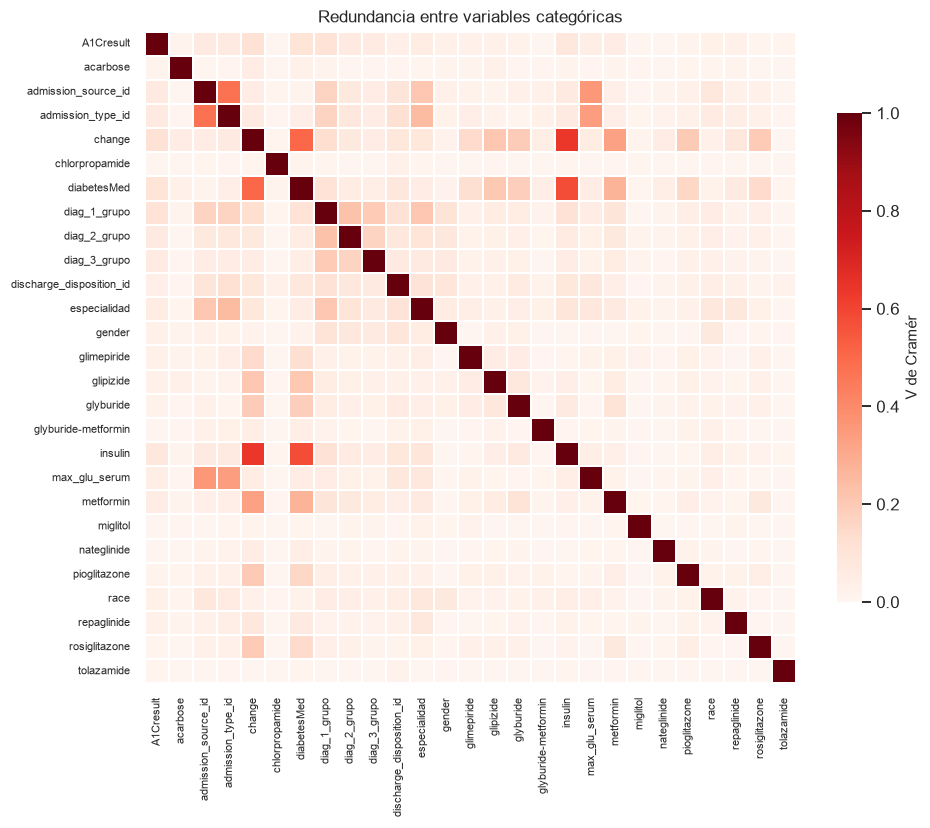

In [6]:
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(matriz_v.astype(float), cmap="Reds", vmin=0, vmax=1, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.75, "label": "V de Cramér"},
            ax=ax)
ax.set_title("Redundancia entre variables categóricas")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

El par más redundante es {glue:text}`c5_par_cat`, con una V de {glue:text}`c5_v_max`. La explicación es estructural: `diabetesMed` indica si se administró algún fármaco antidiabético, `change` si hubo un cambio de medicación e `insulin` es el fármaco más prescrito de la cohorte, de modo que las tres describen parcialmente el mismo hecho clínico. Por detrás quedan los dos identificadores de admisión entre sí y las dos pruebas de laboratorio.

Ningún par alcanza valores que indicarían duplicación: {glue:text}`c5_v_duplicados` pares superan una V de 0.9, el umbral a partir del cual dos variables cuentan lo mismo. Las tres se conservan, y la observación queda registrada para interpretar con cautela los coeficientes de los modelos lineales y las atribuciones de importancia: **la señal se reparte entre variables correlacionadas, lo que puede diluir la importancia individual de cada una sin que eso signifique irrelevancia clínica**. Es un punto que conviene recordar al leer el análisis SHAP del capítulo 10, donde un bloque redundante puede aparecer con tres contribuciones pequeñas en lugar de una grande.

## 5.3. La matriz que los modelos reciben de verdad

Todo lo anterior se ha calculado sobre las variables tal como están en la tabla. Pero ningún modelo ve esa tabla: ven la **matriz codificada** que produce el preprocesador, con una columna por nivel de cada categórica. Sus propiedades geométricas —dimensión, dispersión, condicionamiento— son las que determinan si un modelo lineal converge y si uno basado en distancias tiene sentido, y no se deducen de las tablas anteriores.

Esta sección reproduce aquí el mismo preprocesamiento que el capítulo 6 formaliza como función reutilizable, y lo examina. El ajuste se hace sobre el conjunto de entrenamiento completo y tiene únicamente fines diagnósticos: en el experimento, cada parámetro se estima dentro de su pliegue.

In [7]:
# Réplica del preprocesador del capítulo 6. race se codifica aparte y sin
# agrupación por frecuencia, para conservar desagregado el grupo minoritario
# que exige el análisis de equidad.
categoricas_agrupadas = [c for c in CATEGORICAS if c != "race"]

preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputacion", SimpleImputer(strategy="median")),
                      ("escalado", RobustScaler())]), NUMERICAS),
    ("bin", "passthrough", BINARIAS),
    ("race", OneHotEncoder(handle_unknown="ignore"), ["race"]),
    ("cat", Pipeline([
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("codificacion", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                       min_frequency=0.01))]),
     categoricas_agrupadas),
], verbose_feature_names_out=False, sparse_threshold=0.3)

matriz = preprocesador.fit_transform(train.drop(columns=[OBJETIVO,
                                                         IDENTIFICADOR]))
nombres = preprocesador.get_feature_names_out()

no_nulos = np.asarray((matriz != 0).sum(axis=0)).ravel()
ocupacion = pd.DataFrame({
    "columna": nombres,
    "encuentros con valor distinto de cero": no_nulos,
    "% del conjunto": 100 * no_nulos / matriz.shape[0],
}).sort_values("encuentros con valor distinto de cero")

# Diagnóstico de condicionamiento según el criterio de Belsley: las columnas
# se escalan a norma unitaria, porque de lo contrario el número de condición
# mide la disparidad de unidades y no la dependencia entre columnas. Se
# trabaja con los valores propios de la matriz de Gram, de tamaño manejable,
# en lugar de descomponer la matriz completa.
denso = matriz.toarray() if hasattr(matriz, "toarray") else np.asarray(matriz)
normas = np.linalg.norm(denso, axis=0)
normalizada = denso / np.where(normas == 0, 1, normas)
valores_propios = np.clip(
    np.linalg.eigvalsh(normalizada.T @ normalizada), 0, None)

# Un valor propio indistinguible de cero señala una dependencia lineal
# exacta. Separarlos permite informar dos cosas distintas: cuántas
# dependencias exactas hay y cómo está condicionado el resto del espacio.
tolerancia = valores_propios.max() * len(valores_propios) * np.finfo(float).eps
efectivos = valores_propios[valores_propios > tolerancia]
rango = len(efectivos)
dependencias = matriz.shape[1] - rango
condicion = np.sqrt(efectivos.max() / efectivos.min())

densidad = (matriz.nnz / (matriz.shape[0] * matriz.shape[1])
            if hasattr(matriz, "nnz") else (denso != 0).mean())

anotar("c5_columnas", matriz.shape[1])
anotar("c5_densidad", f"{100 * densidad:.1f}")
anotar("c5_condicion", f"{condicion:,.0f}")
anotar("c5_rango", rango)
anotar("c5_dependencias", dependencias)
anotar("c5_columnas_raras", int((ocupacion["% del conjunto"] < 1).sum()))
anotar("c5_columna_minima", f"{ocupacion['% del conjunto'].min():.2f}")

print(f"Dimensión de la matriz   : {matriz.shape[0]:,} x {matriz.shape[1]}")
print(f"Densidad                 : {100 * densidad:.1f} %")
print(f"Rango numérico           : {rango} "
      f"({dependencias} dependencias lineales exactas)")
print(f"Número de condición      : {condicion:,.1f} "
      "(sobre el subespacio de rango completo)")
tabla(ocupacion.head(12).round(2), filas=12,
      titulo="Columnas menos ocupadas de la matriz codificada", indice=False)

Dimensión de la matriz   : 79,473 x 152
Densidad                 : 22.2 %
Rango numérico           : 125 (27 dependencias lineales exactas)
Número de condición      : 14.0 (sobre el subespacio de rango completo)


### Columnas menos ocupadas de la matriz codificada

La matriz resultante tiene {glue:text}`c5_columnas` columnas y una densidad del {glue:text}`c5_densidad` %, lo que confirma que conviene mantenerla en formato disperso: densificarla multiplicaría por varias veces la memoria sin aportar nada, y con 112 combinaciones que entrenar eso importa. La cifra sirve además de comprobación cruzada: descontando las variables numéricas y la binaria, las columnas one-hot coinciden con las que anticipaba la auditoría de la sección 3.5, de modo que el umbral de frecuencia está haciendo exactamente lo que se esperaba de él.

El diagnóstico de condicionamiento da el resultado que cabía esperar y conviene leerlo en dos partes. La matriz tiene **rango numérico {glue:text}`c5_rango` sobre {glue:text}`c5_columnas` columnas, es decir, {glue:text}`c5_dependencias` dependencias lineales exactas**. Su origen es conocido y no es un defecto: la codificación one-hot sin eliminar una categoría de referencia hace que las columnas de cada variable categórica sumen uno, de modo que cada variable aporta una dependencia. Sobre el subespacio de rango completo, el **número de condición es {glue:text}`c5_condicion`** según el criterio de Belsley, calculado con las columnas escaladas a norma unitaria: un valor por debajo de 30 indica buen condicionamiento, entre 30 y 100 dependencias moderadas, y por encima de 100 colinealidad que puede afectar a la estabilidad numérica de los coeficientes.

La codificación redundante se conserva deliberadamente. Los modelos lineales del proyecto son todos regularizados —Ridge, Lasso, regresión logística con penalización L1 o L2— y la penalización resuelve la indeterminación sin necesidad de rango completo; además, eliminar una categoría por variable haría que los coeficientes se interpretaran contra una referencia arbitraria, lo que complica sin beneficio el análisis SHAP del capítulo 10. Para una regresión sin regularizar sí habría que eliminarla, y eso queda registrado como condición de uso.

La columna menos ocupada de toda la matriz aparece en el {glue:text}`c5_columna_minima` % de los encuentros, y hay {glue:text}`c5_columnas_raras` columnas por debajo del 1 %. Esto conecta con la auditoría del capítulo 3: las columnas escasas son las que pueden quedar constantes dentro de un pliegue concreto de la validación cruzada, y por eso el agrupamiento por frecuencia se aplica **dentro** de cada pliegue y no una sola vez sobre todo el conjunto.

## 5.4. Solapamiento entre clases y techo de desempeño

Esta sección responde la pregunta que debería hacerse cualquier lector del artículo: **¿cuánto se puede aspirar a predecir con estos datos?** Responderla antes de modelar evita las dos lecturas equivocadas que suelen acompañar a un AUC intermedio: presentarlo como un buen resultado sin referencia alguna, o interpretarlo como un fallo de los modelos cuando en realidad es el límite del problema.

Se aborda de dos formas. La primera es visual: se proyectan los encuentros sobre los dos primeros componentes de la matriz codificada y se colorea cada región por su tasa de readmisión. Si las clases fueran separables, aparecerían zonas de color saturado.

La segunda es cuantitativa y es la que aporta el número. Se construye un **clasificador oráculo por perfiles**: se discretiza cada predictor, se forma el perfil que resulta de combinar los `k` más informativos según el capítulo 4 y se asigna a cada encuentro la tasa de readmisión observada en su perfil. Ese clasificador no impone ninguna forma funcional —es la mejor estimación posible de `P(y = 1 | perfil)`— y por tanto marca el techo alcanzable para cualquier modelo que use esos `k` predictores con esa resolución. Para que la estimación sea honesta, la tasa de cada perfil se calcula **fuera de muestra**, con validación cruzada agrupada por paciente: calcularla con los mismos datos con los que se evalúa daría un techo ficticio.

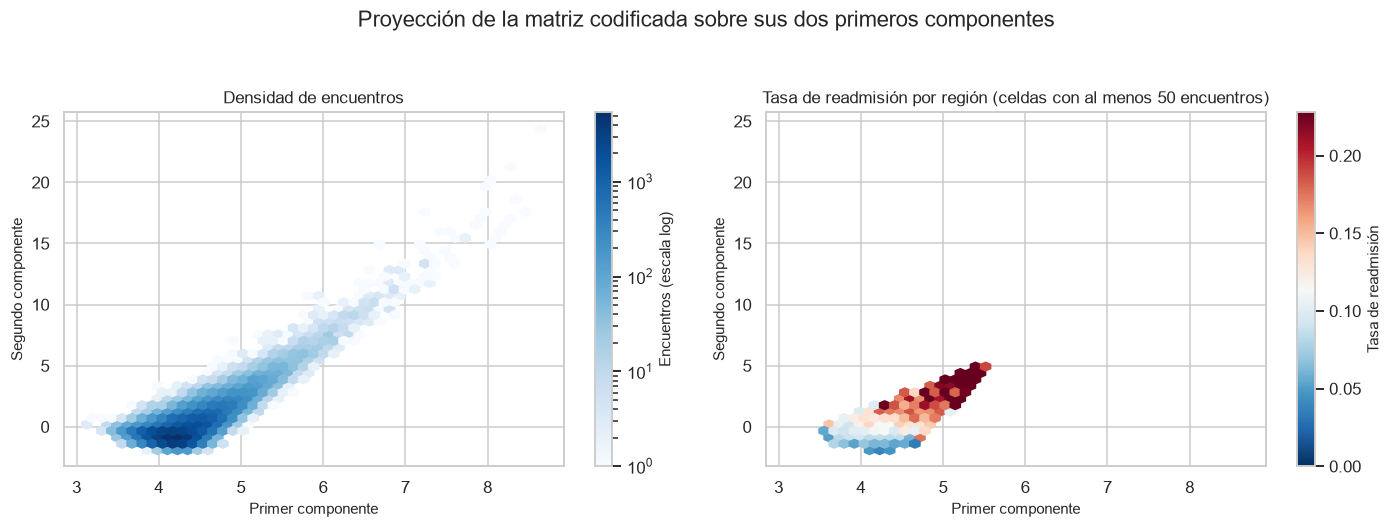

In [8]:
proyeccion = TruncatedSVD(n_components=2, random_state=RANDOM_STATE
                          ).fit_transform(matriz)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
densidad_hex = axes[0].hexbin(proyeccion[:, 0], proyeccion[:, 1], gridsize=45,
                              bins="log", cmap="Blues", mincnt=1)
fig.colorbar(densidad_hex, ax=axes[0], label="Encuentros (escala log)")
axes[0].set_title("Densidad de encuentros")

tasa_hex = axes[1].hexbin(proyeccion[:, 0], proyeccion[:, 1], C=objetivo,
                          gridsize=45, cmap="RdBu_r", mincnt=50,
                          vmin=0, vmax=2 * objetivo.mean())
fig.colorbar(tasa_hex, ax=axes[1], label="Tasa de readmisión")
axes[1].set_title("Tasa de readmisión por región "
                  "(celdas con al menos 50 encuentros)")
for ax in axes:
    ax.set_xlabel("Primer componente")
    ax.set_ylabel("Segundo componente")
fig.suptitle("Proyección de la matriz codificada sobre sus dos primeros "
             "componentes", y=1.04)
plt.tight_layout()
plt.show()

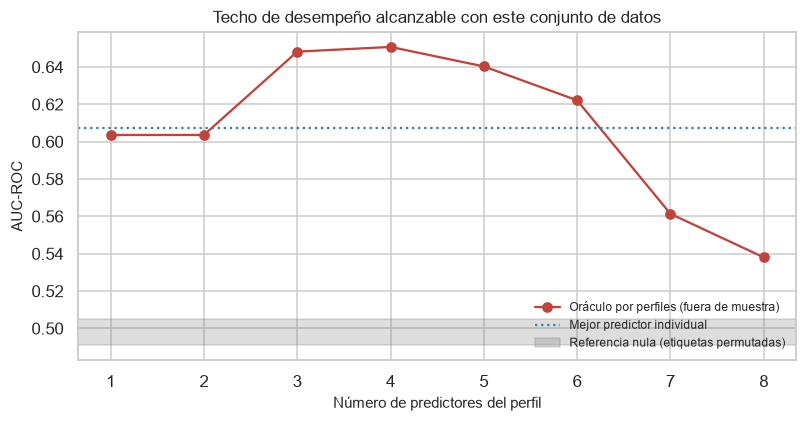

Referencia nula: AUC 0.4989 (rango 0.4909 a 0.5050)


### AUC alcanzable según el número de predictores del perfil

In [9]:
def discretizar(serie, maximo=8):
    """Discretiza un predictor conservando resolución en la cola.

    Las categóricas usan sus niveles. Las numéricas se truncan en el
    percentil 95 —para no crear niveles con un puñado de casos— y se
    conservan sus valores distintos; si aun así superan ``maximo`` niveles,
    se agrupan por cuantiles.
    """
    if serie.dtype.kind not in "biufc":
        return serie.astype("category").cat.codes.to_numpy()
    truncada = serie.clip(upper=serie.quantile(0.95))
    if truncada.nunique() <= maximo:
        return truncada.rank(method="dense").astype(int).to_numpy() - 1
    return pd.qcut(truncada, q=maximo, duplicates="drop").cat.codes.to_numpy()


def auc_oraculo(perfiles, pliegues):
    """AUC fuera de muestra de la tasa observada en cada perfil.

    Returns
    -------
    tuple of float
        AUC y porcentaje de encuentros cuyo perfil no aparecía en los
        pliegues de entrenamiento y recibieron la tasa global.
    """
    puntuacion = np.empty(len(perfiles))
    sin_perfil = 0
    for entreno, evaluacion in pliegues:
        tasas = pd.Series(objetivo[entreno].astype(float)).groupby(
            perfiles[entreno]).mean()
        estimada = pd.Series(perfiles[evaluacion]).map(tasas)
        sin_perfil += int(estimada.isna().sum())
        puntuacion[evaluacion] = estimada.fillna(
            objetivo[entreno].mean()).to_numpy()
    return roc_auc_score(objetivo, puntuacion), 100 * sin_perfil / len(perfiles)


ranking = pd.read_csv(RESULTADOS / "ranking_predictores.csv", index_col=0)
ORDENADOS = [c for c in ranking.index][:8]
pliegues = list(StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
).split(train, objetivo, grupos))

codigos = {c: discretizar(train[c]) for c in ORDENADOS}

filas = []
perfil = np.zeros(len(train), dtype=np.int64)
for k, columna in enumerate(ORDENADOS, start=1):
    perfil = perfil * (codigos[columna].max() + 1) + codigos[columna]
    perfil = pd.Series(perfil).astype("category").cat.codes.to_numpy()
    auc, sin_perfil = auc_oraculo(perfil, pliegues)
    filas.append({
        "predictores usados": k,
        "último añadido": columna,
        "perfiles distintos": int(perfil.max() + 1),
        "AUC del oráculo (fuera de muestra)": auc,
        "% sin perfil conocido": sin_perfil,
    })

techo = pd.DataFrame(filas).set_index("predictores usados")

# Referencia nula: el mismo procedimiento con las etiquetas mezcladas. Marca
# el AUC que se obtendría sin ninguna señal, y su dispersión da la banda de
# ruido con la que hay que comparar cualquier mejora.
generador = np.random.default_rng(RANDOM_STATE)
mejor_k = int(techo["AUC del oráculo (fuera de muestra)"].idxmax())
perfil_mejor = np.zeros(len(train), dtype=np.int64)
for columna in ORDENADOS[:mejor_k]:
    perfil_mejor = perfil_mejor * (codigos[columna].max() + 1) + codigos[columna]
perfil_mejor = pd.Series(perfil_mejor).astype("category").cat.codes.to_numpy()

objetivo_original = objetivo.copy()
nulos = []
for _ in range(20):
    objetivo = generador.permutation(objetivo_original)
    nulos.append(auc_oraculo(perfil_mejor, pliegues)[0])
objetivo = objetivo_original
nulos = np.array(nulos)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(techo.index, techo["AUC del oráculo (fuera de muestra)"], "o-",
        color=PALETA[1], label="Oráculo por perfiles (fuera de muestra)")
ax.axhline(ranking["AUC univariado"].abs().max(), ls=":", color=PALETA[0],
           label="Mejor predictor individual")
ax.axhspan(nulos.min(), nulos.max(), color=GRIS, alpha=0.25,
           label="Referencia nula (etiquetas permutadas)")
ax.set_xlabel("Número de predictores del perfil")
ax.set_ylabel("AUC-ROC")
ax.set_title("Techo de desempeño alcanzable con este conjunto de datos")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

guardar_resultado(techo, "techo_desempeno")
anotar("c5_techo", f"{techo['AUC del oráculo (fuera de muestra)'].max():.3f}")
anotar("c5_techo_k", mejor_k)
anotar("c5_techo_vars", ", ".join(ORDENADOS[:mejor_k]))
anotar("c5_univariado", f"{ranking['AUC univariado'].abs().max():.3f}")
anotar("c5_nulo", f"{nulos.mean():.3f}")
anotar("c5_caida", f"{techo['AUC del oráculo (fuera de muestra)'].iloc[-1]:.3f}")
anotar("c5_perfiles_ultimo", f"{techo['perfiles distintos'].iloc[-1]:,}")
anotar("c5_sin_perfil_ultimo", f"{techo['% sin perfil conocido'].iloc[-1]:.1f}")
print(f"Referencia nula: AUC {nulos.mean():.4f} "
      f"(rango {nulos.min():.4f} a {nulos.max():.4f})")
tabla(techo.round(4), filas=10,
      titulo="AUC alcanzable según el número de predictores del perfil")

El panel de la izquierda muestra que los encuentros forman una nube compacta, sin agrupaciones separadas. El de la derecha es el que importa: **casi ninguna región alcanza una tasa de readmisión muy distinta de la global**. No hay ningún bolsillo del espacio donde la clase positiva se concentre. Las clases se solapan casi por completo, que es la traducción geométrica de todo lo que el capítulo 4 encontró variable por variable.

La curva del techo pone número a esa intuición. El oráculo por perfiles alcanza su máximo con {glue:text}`c5_techo_k` predictores ({glue:text}`c5_techo_vars`) y llega a un **AUC de {glue:text}`c5_techo` fuera de muestra**, frente a {glue:text}`c5_univariado` del mejor predictor individual y {glue:text}`c5_nulo` de la referencia nula. Tres lecturas se siguen de ahí.

**Primera: el margen de mejora sobre un solo predictor es de unas cuatro centésimas de AUC.** Esto confirma con una segunda metodología la conclusión de la sección 4.6, obtenida por información de interacción. Que dos caminos independientes den la misma respuesta es la mejor validación disponible sin entrenar nada.

**Segunda: ese es el techo, no un objetivo.** Un modelo que alcance un AUC cercano a {glue:text}`c5_techo` no está funcionando mal: está agotando la información que estos predictores contienen. La conclusión que corresponde escribir en el artículo no es "los modelos rinden poco", sino "los datos administrativos de este registro no contienen más señal que esta, y eso es un hallazgo sobre el problema de la readmisión, no sobre los algoritmos".

**Tercera, y es la que justifica todo el pipeline: añadir predictores al oráculo empeora el resultado.** Con los ocho predictores el AUC cae a {glue:text}`c5_caida`, porque el número de perfiles distintos crece hasta {glue:text}`c5_perfiles_ultimo` y el {glue:text}`c5_sin_perfil_ultimo` % de los encuentros de evaluación tiene un perfil que nunca apareció en entrenamiento. Es la maldición de la dimensionalidad en su forma más nítida, y explica exactamente qué aporta el modelo base del capítulo 7 frente a una tabla de consulta: **compartir información entre perfiles parecidos en lugar de tratarlos como categorías independientes**. Un modelo con la regularización adecuada debería igualar o superar el máximo de esta curva usando todos los predictores, sin sufrir la caída. Si no lo consigue, el problema está en el modelo o en su ajuste, no en los datos.

## 5.5. Revisión de fuga de información

Un predictor solo es admisible si su valor está disponible **en el momento del alta**, que es cuando el modelo debería emitir su predicción en un uso real. Se revisa cada bloque bajo ese criterio.

| Bloque | ¿Disponible al alta? | Decisión |
|---|---|---|
| Demográficas (`race`, `gender`, `age_ord`) | Sí, desde el ingreso | Se conservan. `race` queda sin agrupar por frecuencia para el análisis de equidad |
| Administrativas (`admission_type_id`, `admission_source_id`) | Sí, desde el ingreso | Se conservan |
| `discharge_disposition_id` | Sí, se determina al alta | Se conserva. Es el predictor categórico más asociado y su uso es legítimo |
| Utilización previa (`number_outpatient`, `number_emergency`, `number_inpatient`, `hospitalizacion_previa`) | Sí, corresponde al año anterior | Se conservan. Son los predictores más informativos del conjunto |
| Proceso del ingreso (`time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`) | Sí, se conocen al cierre del episodio | Se conservan |
| Laboratorio (`A1Cresult`, `max_glu_serum`) | Sí | Se conservan, incluida la categoría de prueba no realizada, que es la más informativa del bloque |
| Fármacos, `change`, `diabetesMed`, `n_farmacos_activos` | Sí | Se conservan |
| `readmitted` | **No**: es el desenlace | Eliminada tras derivar el target |
| Número de encuentros del paciente | **No**: depende de episodios futuros | Nunca se construye como predictor. Se usó en el capítulo 3 solo como diagnóstico |
| `patient_nbr` | Identificador | Se conserva solo para trazabilidad y agrupamiento; nunca como predictor |
| `encounter_id` | Identificador secuencial | Eliminado en el capítulo 2: al ser creciente en el tiempo permitiría captar tendencias del registro en lugar del mecanismo clínico |

No hay fuga en sentido estricto entre los predictores. Los dos riesgos reales de este proyecto son de otra naturaleza y ambos están tratados:

1. **La dependencia entre encuentros del mismo paciente.** El capítulo 3 la cuantificó y mostró que los predictores se repiten dentro del paciente mucho más que la etiqueta. Se resuelve con `StratifiedGroupKFold` agrupado por `patient_nbr`, tanto en la partición del capítulo 2 como en cada nivel de la validación anidada.
2. **La estimación de parámetros de preprocesamiento fuera de los pliegues.** La imputación, el escalado, la codificación y sobre todo el remuestreo sintético estiman parámetros a partir de los datos. Se resuelve declarándolos como etapas de un `Pipeline` que se ajusta dentro de cada pliegue, nunca antes.

Conviene subrayar por qué el segundo riesgo es más grave de lo que parece con SMOTE y ADASYN: esas técnicas **generan observaciones nuevas interpolando entre vecinos**. Si se aplicaran antes de particionar, una muestra sintética podría interpolar entre un encuentro que queda en entrenamiento y otro que queda en validación, de modo que el modelo vería una versión mezclada del dato con el que después se le evalúa. El efecto es mucho mayor que el de un escalado mal colocado, y es la razón por la que el pipeline usa `imbalanced-learn` y no una llamada suelta a SMOTE.

### 5.5.1. Sobre la rama de regresión

La guía del entregable plantea también una rama de regresión, cuyo objetivo natural sería `time_in_hospital`. **Queda fuera del alcance de este trabajo**, que se limita a la tarea de clasificación, pero conviene dejar registrado por qué no se trata como un ejercicio equivalente.

Predecir los días de estancia con las variables de este conjunto sería **fuga de información por construcción**: `num_lab_procedures`, `num_procedures` y `num_medications` son concurrentes con la estancia, es decir, se acumulan durante los días de hospitalización. Usarlas para predecir la duración de esa misma estancia es explicar una variable con sus propias consecuencias, y explica buena parte de las correlaciones de la sección 5.1. Un planteamiento defendible tendría que restringir los predictores a lo conocido en el momento del **ingreso** —demografía, tipo y fuente de admisión, diagnósticos, utilización previa— o bien declarar explícitamente que el ejercicio es descriptivo y no predictivo.

Hay además una segunda objeción, sobre las pruebas estadísticas que la guía asocia a esa rama. Los contrastes de White, BDS, Ljung-Box, el conjunto de modelos de confianza y las pruebas de Giacomini-White y Diebold-Mariano están diseñados para **series temporales o secuencias de predicción**. Estos datos son transversales: no hay ordenación temporal genuina, y el capítulo 2 eliminó `encounter_id` precisamente para que ningún modelo la usara. Aplicar esas pruebas exigiría construir un orden artificial y declarar el supuesto, o adaptar el contraste a pérdidas por observación.

## 5.6. Resumen ejecutivo del análisis exploratorio

La tabla siguiente consolida los hallazgos de los tres capítulos exploratorios. Se construye leyendo las síntesis que los capítulos 3 y 4 guardaron en `results/`, de modo que no puede desincronizarse de ellos.

In [10]:
def cargar_sintesis(nombre, capitulo):
    """Lee la síntesis guardada por un capítulo previo, si está disponible."""
    ruta = RESULTADOS / f"{nombre}.csv"
    if not ruta.exists():
        return pd.DataFrame(columns=["Capítulo", "Dimensión", "Hallazgo"])
    datos = pd.read_csv(ruta, index_col=0)
    datos.insert(0, "Capítulo", capitulo)
    return datos


resumen_capitulo_5 = pd.DataFrame([
    ("5. Síntesis", "Colinealidad numérica",
     f"Todos los VIF por debajo de 5 (máximo {vif['VIF'].max():.2f} en "
     f"{vif.index[0]}) tras eliminar la variable con dependencia exacta"),
    ("5. Síntesis", "Redundancia categórica",
     f"Par más redundante: {pares_cat.iloc[0]['variable_1']} y "
     f"{pares_cat.iloc[0]['variable_2']} "
     f"(V = {pares_cat['V de Cramér'].iloc[0]:.2f}); ninguno supera 0.9, "
     "así que no se elimina ninguna variable"),
    ("5. Síntesis", "Matriz codificada",
     f"{matriz.shape[1]} columnas, densidad del {100 * densidad:.1f} %, rango "
     f"numérico {rango} ({dependencias} dependencias exactas por el one-hot "
     f"sin categoría de referencia) y número de condición {condicion:,.0f} "
     "sobre el subespacio de rango completo"),
    ("5. Síntesis", "Solapamiento de clases",
     "Ninguna región de la proyección concentra la clase positiva: las "
     "clases se solapan casi por completo"),
    ("5. Síntesis", "Techo de desempeño",
     f"AUC de {techo['AUC del oráculo (fuera de muestra)'].max():.3f} fuera "
     f"de muestra con {mejor_k} predictores, frente a "
     f"{ranking['AUC univariado'].abs().max():.3f} del mejor predictor "
     f"individual y {nulos.mean():.3f} de la referencia nula"),
    ("5. Síntesis", "Maldición de la dimensionalidad",
     f"El oráculo cae a {techo['AUC del oráculo (fuera de muestra)'].iloc[-1]:.3f} "
     f"con ocho predictores y {techo['perfiles distintos'].iloc[-1]:,} "
     "perfiles: es lo que la regularización debe evitar"),
    ("5. Síntesis", "Fuga de información",
     "Ausente entre los predictores. Los riesgos reales son la dependencia "
     "entre encuentros y el preprocesamiento fuera de pliegue, ambos "
     "resueltos por diseño"),
], columns=["Capítulo", "Dimensión", "Hallazgo"])

resumen = pd.concat([
    cargar_sintesis("sintesis_univariado", "3. Univariado"),
    cargar_sintesis("sintesis_bivariado", "4. Bivariado"),
    resumen_capitulo_5,
], ignore_index=True)

guardar_resultado(resumen, "sintesis_eda")
tabla(resumen, filas=40, titulo="Resumen ejecutivo del análisis exploratorio",
      indice=False)

### Resumen ejecutivo del análisis exploratorio

## 5.7. Implicaciones para el modelado

Las decisiones del pipeline experimental se siguen de lo anterior, y cada una tiene detrás una sección concreta de estos tres capítulos.

1. **Todo el preprocesamiento va dentro del pipeline.** La codificación de categóricas, el escalado robusto y el balanceo estiman parámetros a partir de los datos. Se implementan como etapas de un `Pipeline` de `imbalanced-learn` ajustado dentro de cada pliegue de la validación cruzada anidada (sección 5.5).

2. **La validación cruzada se agrupa por paciente en ambos niveles.** No es una precaución opcional: los predictores se repiten dentro del paciente mucho más que la etiqueta, de modo que una partición por filas premiaría reconocer al paciente en lugar de estimar su riesgo (sección 3.2).

3. **Métricas principales: AUC-ROC y AUC de precisión-exhaustividad**, complementadas con F1 de la clase positiva y exactitud balanceada. La exactitud se reporta solo como referencia, nunca como criterio de selección (sección 3.1).

4. **El balanceo se trata como una dimensión experimental**, no como un paso obligatorio: la ausencia de tratamiento es una de las cuatro alternativas y puede ganar. El desbalance de este conjunto es moderado, lo que hace la comparación genuinamente incierta (sección 3.1).

5. **Escalado robusto, sin recorte de atípicos.** Ninguna variable numérica es normal y los valores extremos de la utilización previa son los encuentros más informativos del conjunto, no errores de captura (secciones 3.3.2 y 3.3.3).

6. **Las expectativas de desempeño están cuantificadas y son moderadas, y eso es un hallazgo.** El mejor predictor individual alcanza un AUC de {glue:text}`c5_univariado` y el techo estimado fuera de muestra es de {glue:text}`c5_techo`. Un modelo que se sitúe en ese entorno está agotando la señal disponible. Esta cifra debe aparecer en el artículo **antes** de los resultados, no después, para que el lector los interprete correctamente.

7. **Los modelos capaces de representar interacciones deberían aventajar a los aditivos, por un margen pequeño.** La información de interacción y la curva del techo coinciden en que la ganancia disponible es de unas centésimas de AUC. La hipótesis se contrasta formalmente con la secuencia de Friedman y el diagrama de diferencia crítica, no comparando medias a ojo (secciones 4.6 y 5.4).

8. **La colinealidad no exige eliminar variables**, pero condiciona la interpretación: en el bloque `insulin`-`change`-`diabetesMed` la importancia se reparte entre variables correlacionadas, lo que conviene recordar al leer el análisis SHAP (secciones 5.1 y 5.2).

9. **La equidad se evalúa sobre las predicciones, no sobre los datos.** Las tasas base por atributo protegido quedaron registradas en la sección 4.8 como línea de comparación; la ausencia de asociación marginal no garantiza paridad en las predicciones.